In [1]:
import os
import numpy as np
import scipy.io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def load_z24_bridge_data(classes, dataset_dir='./DatasetPDT/', window_size=65536):
    dataset = []
    labels = []
    for class_num in classes:
        class_path = os.path.join(dataset_dir, class_num, 'avt/')
        for file_name in os.listdir(class_path):
            if file_name.endswith('.mat'):
                data = scipy.io.loadmat(os.path.join(class_path, file_name))['data'].T
                for segment in data:
                    if len(segment) < window_size:
                        segment = np.pad(segment, (0, window_size - len(segment)), 'edge')
                    dataset.append(segment)
                    labels.append(classes.index(class_num))
    dataset = np.array(dataset)
    labels = np.array(labels)

    # Standardize the dataset
    scaler = StandardScaler()
    dataset = scaler.fit_transform(dataset)

    # Split the dataset into training, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(dataset, labels, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    return X_train, X_val, X_test, y_train, y_val, y_test


# Define the classes to use (e.g., for 5-class problem)
classes = ['01', '03', '04', '05', '06']
X_train, X_val, X_test, y_train, y_val, y_test = load_z24_bridge_data(classes)

# Reshape the data for the neural network input
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers


def build_nn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Neural network layers with L2 regularization and dropout
    x = layers.Conv1D(16, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(32, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, x)
    return model


input_shape = (X_train.shape[1], 1)
num_classes = len(classes)
model = build_nn(input_shape, num_classes)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()


2025-11-13 14:47:29.348940: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-13 14:47:29.470707: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-13 14:47:29.471683: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 14:47:31.046174: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 65536, 1)]        0         
                                                                 
 conv1d (Conv1D)             (None, 65536, 16)         64        
                                                                 
 max_pooling1d (MaxPooling1D  (None, 32768, 16)        0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 32768, 32)         1568      
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 16384, 32)        0         
 1D)                                                             
                                                                 
 flatten (Flatten)           (None, 524288)            0     

In [3]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, verbose=1)
model_checkpoint = ModelCheckpoint('best_nn_model_v2.keras', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)


Epoch 1/200
16/16 [==============================] - ETA: 0s - loss: 3.0433 - accuracy: 0.1986
Epoch 1: val_loss improved from inf to 1.87671, saving model to best_nn_model_v2.keras
16/16 [==============================] - 16s 925ms/step - loss: 3.0433 - accuracy: 0.1986 - val_loss: 1.8767 - val_accuracy: 0.1881 - lr: 0.0010
Epoch 2/200
16/16 [==============================] - ETA: 0s - loss: 2.2853 - accuracy: 0.2016
Epoch 2: val_loss did not improve from 1.87671
16/16 [==============================] - 10s 621ms/step - loss: 2.2853 - accuracy: 0.2016 - val_loss: 1.8885 - val_accuracy: 0.1881 - lr: 0.0010
Epoch 3/200
16/16 [==============================] - ETA: 0s - loss: 2.2807 - accuracy: 0.2262
Epoch 3: val_loss improved from 1.87671 to 1.84854, saving model to best_nn_model_v2.keras
16/16 [==============================] - 14s 898ms/step - loss: 2.2807 - accuracy: 0.2262 - val_loss: 1.8485 - val_accuracy: 0.1743 - lr: 0.0010
Epoch 4/200
16/16 [==============================] - ET

In [4]:
# Evaluate the model
model = tf.keras.models.load_model('best_nn_model_v2.keras')
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

7/7 [==============================] - 1s 60ms/step - loss: 0.4644 - accuracy: 0.9771
Test accuracy: 97.71%


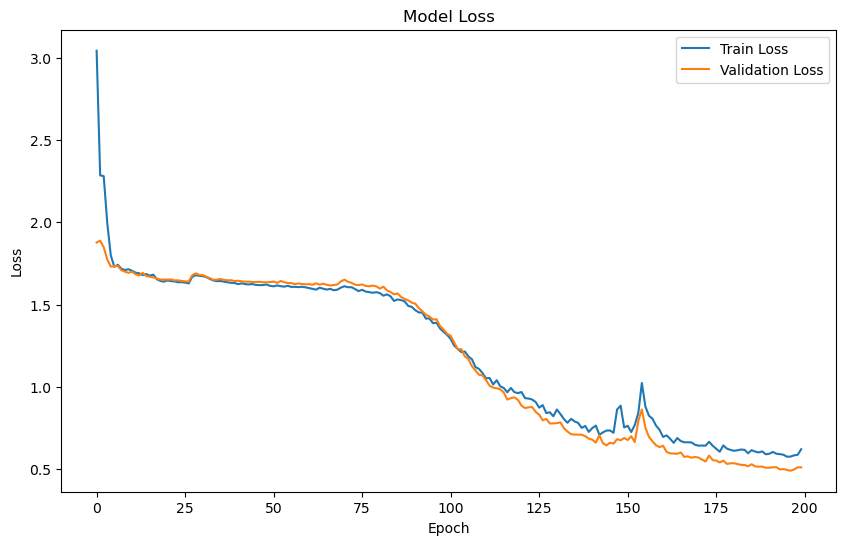

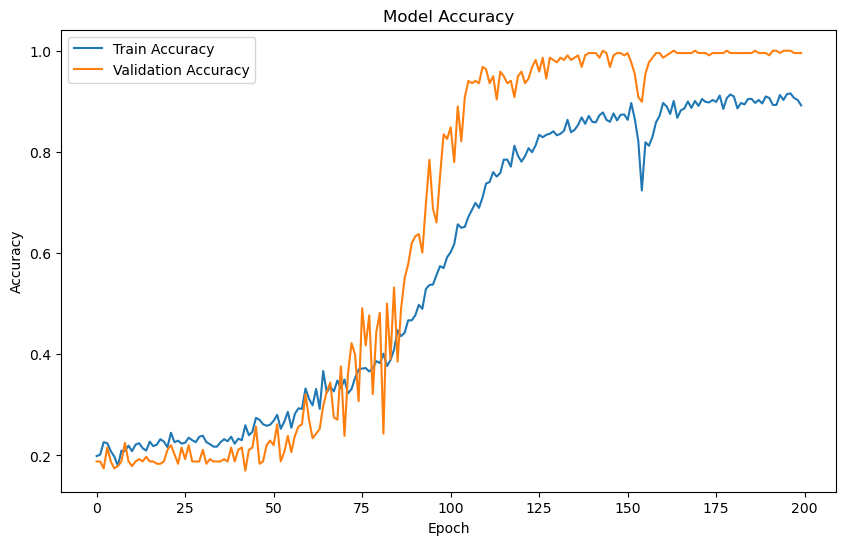

In [5]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.savefig('nn_training_validation_loss_v2.png')

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.savefig('nn_training_validation_accuracy_v2.png')


In [6]:
# ================== EXPORT ARTIFACTS — NN_V2 ==================
# À placer après l'entraînement (après model.fit)
import os, json, time, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

RUN_NAME = "NN_V2"
OUT_DIR  = Path("outputs") / RUN_NAME
FIG_DIR  = OUT_DIR / "figs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---- Récupération robuste de l'historique ----
_hist = history.history if hasattr(history, "history") else history  # 'history' doit exister

def pick(d, *keys, default=None):
    for k in keys:
        if k in d:
            return np.asarray(d[k])
    return np.asarray([]) if default is None else np.asarray(default)

acc      = pick(_hist, "accuracy", "acc")
val_acc  = pick(_hist, "val_accuracy", "val_acc")
loss     = pick(_hist, "loss")
val_loss = pick(_hist, "val_loss")

np.savez(OUT_DIR / "history.npz",
         accuracy=acc, val_accuracy=val_acc, loss=loss, val_loss=val_loss)
np.savetxt(OUT_DIR / "history_accuracy.csv",
           np.c_[np.arange(1, len(acc)+1), acc, val_acc],
           delimiter=",", header="epoch,accuracy,val_accuracy", comments="")
np.savetxt(OUT_DIR / "history_loss.csv",
           np.c_[np.arange(1, len(loss)+1), loss, val_loss],
           delimiter=",", header="epoch,loss,val_loss", comments="")

# ---- Détection souple des variables test (adapte si besoin) ----
def get_var(names):
    for n in names:
        if n in globals():
            return globals()[n]
    return None

X_test = get_var(["X_test", "x_test", "Xte", "x_te", "X_val", "x_val"])
y_test = get_var(["y_test", "Y_test", "yte", "y_te", "y_val", "Y_val"])
if X_test is None or y_test is None:
    raise ValueError("X_test/y_test introuvables. Renomme-les ou renseigne les bons noms ci-dessus.")

# y_true en entiers; gère le one-hot
y_true = y_test if getattr(y_test, "ndim", 1) == 1 else np.argmax(y_test, axis=1)

# ---- Prédictions & métriques ----
y_prob = model.predict(X_test, verbose=0)

# Uniformiser pour AUC/argmax
if y_prob.ndim == 1:
    y_prob = y_prob.reshape(-1, 1)
if y_prob.shape[1] == 1:
    y_prob = np.column_stack([1 - y_prob.ravel(), y_prob.ravel()])

y_pred = np.argmax(y_prob, axis=1)

np.savez(OUT_DIR / "test_preds.npz", y_true=y_true, y_pred=y_pred, y_prob=y_prob)

cm = confusion_matrix(y_true, y_pred)
np.savetxt(OUT_DIR / "confusion_matrix.csv", cm, fmt="%d", delimiter=",")

rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
with open(OUT_DIR / "classification_report.json", "w") as f:
    json.dump(rep, f, indent=2)

# AUC macro (multi-classe) / AUC binaire selon le cas
auc_macro = None
try:
    if y_prob.shape[1] > 2:
        auc_macro = float(roc_auc_score(y_true, y_prob, average="macro", multi_class="ovr"))
    else:
        auc_macro = float(roc_auc_score(y_true, y_prob[:, 1]))
except Exception:
    pass

runinfo = {
    "run_name": RUN_NAME,
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "n_epochs": int(len(loss)),
    "best_val_acc": float(val_acc.max()) if val_acc.size else None,
    "best_val_loss": float(val_loss.min()) if val_loss.size else None,
    "auc_macro": auc_macro,
}
with open(OUT_DIR / "runinfo.json", "w") as f:
    json.dump(runinfo, f, indent=2)

# ---- Figures HD (lignes épaisses, police plus grande) ----
plt.rcParams.update({
    "font.size": 12, "axes.labelsize": 12, "axes.titlesize": 12, "legend.fontsize": 10
})

plt.figure(figsize=(7,4), dpi=300)
plt.plot(acc, label="Train Accuracy", linewidth=2.2)
plt.plot(val_acc, label="Validation Accuracy", linewidth=2.2)
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.grid(True, alpha=.3); plt.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "accuracy.png", bbox_inches="tight"); plt.close()

plt.figure(figsize=(7,4), dpi=300)
plt.plot(loss, label="Train Loss", linewidth=2.2)
plt.plot(val_loss, label="Validation Loss", linewidth=2.2)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True, alpha=.3); plt.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "loss.png", bbox_inches="tight"); plt.close()

plt.figure(figsize=(5,4), dpi=300)
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix"); plt.colorbar()
ticks = np.arange(cm.shape[0])
plt.xticks(ticks, ticks); plt.yticks(ticks, ticks)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.savefig(FIG_DIR / "confusion_matrix.png", bbox_inches="tight"); plt.close()

# (Optionnel) Sauvegarde du modèle Keras
try:
    model.save(OUT_DIR / "model.keras")
except Exception:
    pass

print(f"[{RUN_NAME}] Export terminé -> {OUT_DIR}")
# ================== FIN EXPORT ==================


[NN_V2] Export terminé -> outputs/NN_V2


In [7]:
# après l’entraînement et l’éval
y_prob_test = model.predict(X_test, batch_size=256, verbose=0)
y_true_test = y_test.copy()

from pathlib import Path
import numpy as np
out = Path("./outputs"); out.mkdir(parents=True, exist_ok=True)
np.savez_compressed(out/"predictions_NN_V2.npz", y_true_test=y_true_test, y_prob_test=y_prob_test)  # idem V2/V3
